In [1]:
import pandas as pd

orders_df = pd.read_csv('orders.csv')
display(orders_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 3421083 entries, 0 to 3421082
Data columns (total 7 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   eval_set                str    
 3   order_number            int64  
 4   order_dow               int64  
 5   order_hour_of_day       int64  
 6   days_since_prior_order  float64
dtypes: float64(1), int64(5), str(1)
memory usage: 182.7 MB


None

In [2]:
display(orders_df.head())

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc dữ liệu 
orders_df = pd.read_csv('orders.csv')
prior_df = pd.read_csv('order_products__prior.csv') 

num_users = orders_df['user_id'].nunique()
num_orders = orders_df['order_id'].nunique()
num_products = prior_df['product_id'].nunique()

print(f"Tổng số User: {num_users:,}")
print(f"Tổng số Đơn hàng (Orders): {num_orders:,}")
print(f"Tổng số Sản phẩm (Products): {num_products:,}")

# Gộp bảng để biết ai đã mua sản phẩm gì
orders_lite = orders_df[['order_id', 'user_id', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']]

print("\nĐang gộp 2 bảng lại với nhau...")
merged_df = pd.merge(prior_df, orders_lite, on='order_id', how='inner')

# Trung bình 1 đơn hàng có bao nhiêu sản phẩm?
items_per_order = merged_df.groupby('order_id').size()
print(f"\nTrung bình mỗi đơn hàng có: {items_per_order.mean():.2f} sản phẩm")

# Trung bình 1 User có bao nhiêu đơn hàng?
orders_per_user = orders_df.groupby('user_id')['order_number'].max()
print(f"Trung bình một người dùng đặt: {orders_per_user.mean():.2f} đơn hàng")

display(merged_df.head())

Tổng số User: 206,209
Tổng số Đơn hàng (Orders): 3,421,083
Tổng số Sản phẩm (Products): 49,677

Đang gộp 2 bảng lại với nhau...

Trung bình mỗi đơn hàng có: 10.09 sản phẩm
Trung bình một người dùng đặt: 16.59 đơn hàng


,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2,33120,1,1,202279,3,5,9,8.0
1,2,28985,2,1,202279,3,5,9,8.0
2,2,9327,3,0,202279,3,5,9,8.0
3,2,45918,4,1,202279,3,5,9,8.0
4,2,30035,5,0,202279,3,5,9,8.0


C:\Users\DELL\AppData\Local\Temp\ipykernel_8740\2825651457.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_ids.values, y=top_10_names.values, ax=axes[1, 0], palette='viridis')


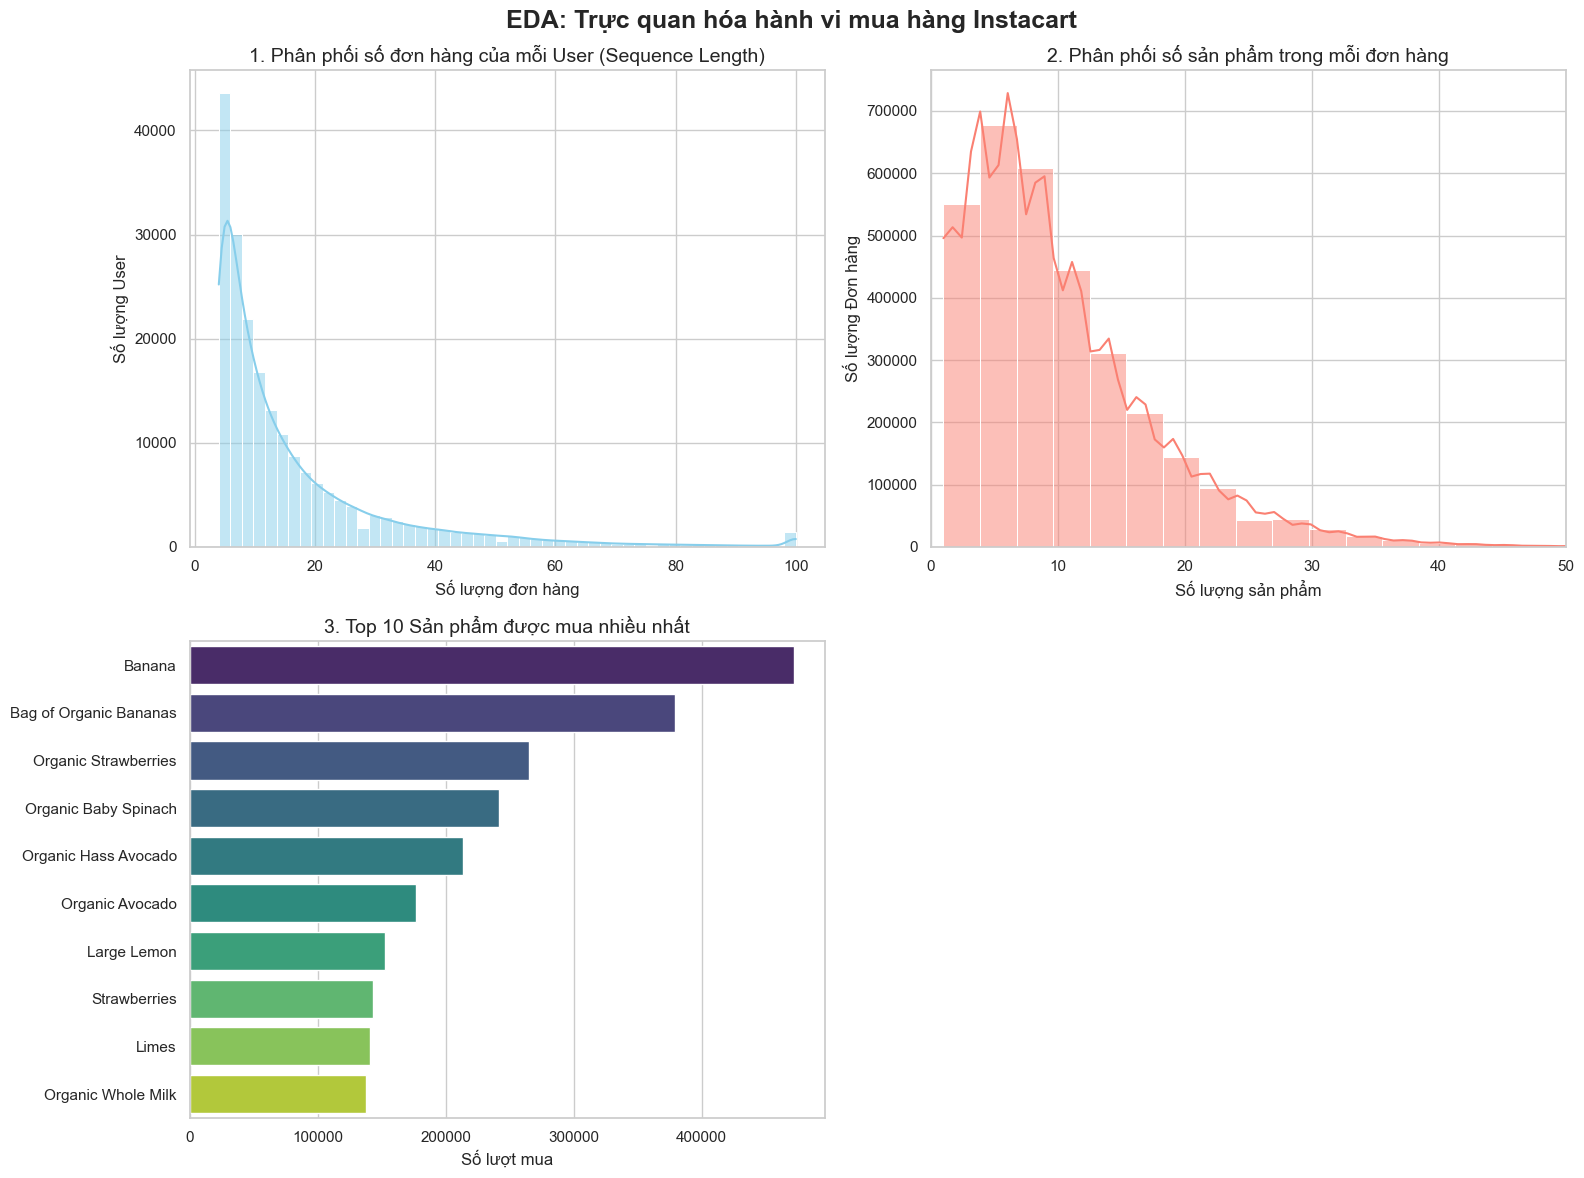

Hoàn tất!


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('EDA: Trực quan hóa hành vi mua hàng Instacart', fontsize=18, fontweight='bold')

# --- BIỂU ĐỒ 1: Phân phối số lượng đơn hàng / User ---
orders_per_user = orders_df.groupby('user_id')['order_number'].max()
sns.histplot(orders_per_user, bins=50, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('1. Phân phối số đơn hàng của mỗi User (Sequence Length)', fontsize=14)
axes[0, 0].set_xlabel('Số lượng đơn hàng')
axes[0, 0].set_ylabel('Số lượng User')

# --- BIỂU ĐỒ 2: Phân phối số lượng sản phẩm / Đơn hàng ---
items_per_order = merged_df.groupby('order_id').size()
sns.histplot(items_per_order, bins=50, kde=True, ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('2. Phân phối số sản phẩm trong mỗi đơn hàng', fontsize=14)
axes[0, 1].set_xlabel('Số lượng sản phẩm')
axes[0, 1].set_ylabel('Số lượng Đơn hàng')
axes[0, 1].set_xlim(0, 50) # Giới hạn trục X ở mức 50 để dễ nhìn (bỏ qua các đơn quá bất thường)

# --- BIỂU ĐỒ 3: Top 10 sản phẩm bán chạy nhất ---
products_df = pd.read_csv('products.csv')

# Lấy top 10 ID sản phẩm bán chạy nhất
top_10_ids = merged_df['product_id'].value_counts().head(10)

# Ghép với bảng products_df để lấy tên thực tế
top_10_names = products_df.set_index('product_id').loc[top_10_ids.index, 'product_name']

sns.barplot(x=top_10_ids.values, y=top_10_names.values, ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('3. Top 10 Sản phẩm được mua nhiều nhất', fontsize=14)
axes[1, 0].set_xlabel('Số lượt mua')
axes[1, 0].set_ylabel('')

# Ẩn ô biểu đồ thứ 4 bị thừa ở góc dưới bên phải
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()
print("Hoàn tất!")

In [10]:
#LÀM SẠCH DỮ LIỆU

# 1. Kiểm tra giá trị thiếu
missing_values = merged_df.isnull().sum()
print("\n1. Số lượng giá trị Null ở mỗi cột:")
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "Tuyệt vời! Không có giá trị Null nào.")

# 2. Kiểm tra dữ liệu trùng lặp 
duplicates = merged_df.duplicated().sum()
print(f"\n2. Số dòng bị trùng lặp hoàn toàn: {duplicates:,}")
if duplicates > 0:
    print("Đang xóa các dòng trùng lặp...")
    merged_df = merged_df.drop_duplicates()

# 3. Kiểm tra và tối ưu kiểu dữ liệu 
print("\n3. Kiểu dữ liệu hiện tại:")
print(merged_df.dtypes)

# Tối ưu RAM: Ép kiểu dữ liệu
merged_df['order_id'] = merged_df['order_id'].astype('int32')
merged_df['user_id'] = merged_df['user_id'].astype('int32')
merged_df['product_id'] = merged_df['product_id'].astype('int32')
merged_df['order_number'] = merged_df['order_number'].astype('int16')

# 4. Kiểm tra logic sau khi gộp bảng 
# Đảm bảo không có user nào bị mất dữ liệu order_number sau khi gộp
invalid_orders = merged_df[merged_df['order_number'] <= 0]
print(f"\n4. Số dòng có order_number không hợp lệ (<= 0): {len(invalid_orders)}")



1. Số lượng giá trị Null ở mỗi cột:
days_since_prior_order    2078068
dtype: int64

2. Số dòng bị trùng lặp hoàn toàn: 0

3. Kiểu dữ liệu hiện tại:
order_id                    int64
product_id                  int64
add_to_cart_order           int64
reordered                   int64
user_id                     int64
order_number                int64
order_dow                   int64
order_hour_of_day           int64
days_since_prior_order    float64
dtype: object

4. Số dòng có order_number không hợp lệ (<= 0): 0


In [11]:
import pickle

MIN_INTERACTIONS = 20  # Ít nhất 20 tương tác 
MIN_ORDERS = 5         # Ít nhất 5 đơn hàng
TOP_N_PRODUCTS = 10000 # top 10,000 sản phẩm

print(f"Kích thước ban đầu: {len(merged_df):,} dòng")

# 1. LỌC SẢN PHẨM: Giữ top 10,000 sản phẩm phổ biến
top_products = merged_df['product_id'].value_counts().nlargest(TOP_N_PRODUCTS).index
filtered_df = merged_df[merged_df['product_id'].isin(top_products)]

# 2. LỌC USER: 
# Đếm số interaction (số dòng) của mỗi user
interaction_counts = filtered_df.groupby('user_id').size()
users_pass_interactions = interaction_counts[interaction_counts >= MIN_INTERACTIONS].index

# Đếm số order (số đơn hàng duy nhất) của mỗi user
order_counts = filtered_df.groupby('user_id')['order_id'].nunique()
users_pass_orders = order_counts[order_counts >= MIN_ORDERS].index

# Lấy giao của 2 tập hợp (User phải nằm trong cả 2 danh sách trên)
valid_users = users_pass_interactions.intersection(users_pass_orders)

filtered_df = filtered_df[filtered_df['user_id'].isin(valid_users)]

print(f"\nKích thước sau khi lọc: {len(filtered_df):,} dòng")
print(f"Số lượng User còn lại (>= 20 items VÀ >= 5 orders): {filtered_df['user_id'].nunique():,}")
print(f"Số lượng Sản phẩm còn lại: {filtered_df['product_id'].nunique():,}")

# 3. ENCODE DATA VÀ LƯU FILE
user_ids = filtered_df['user_id'].unique()
user2idx = {old_id: new_idx for new_idx, old_id in enumerate(user_ids)}

product_ids = filtered_df['product_id'].unique()
product2idx = {old_id: new_idx for new_idx, old_id in enumerate(product_ids)}

filtered_df['user_idx'] = filtered_df['user_id'].map(user2idx)
filtered_df['product_idx'] = filtered_df['product_id'].map(product2idx)

with open('user2idx.pkl', 'wb') as f:
    pickle.dump(user2idx, f)
    
with open('product2idx.pkl', 'wb') as f:
    pickle.dump(product2idx, f)

print("Lọc và lưu file mapping thành công!")

Kích thước ban đầu: 32,434,489 dòng

Kích thước sau khi lọc: 28,133,341 dòng
Số lượng User còn lại (>= 20 items VÀ >= 5 orders): 154,215
Số lượng Sản phẩm còn lại: 10,000
Lọc và lưu file mapping thành công!


In [7]:
# --- THỐNG KÊ LẠI SAU KHI LỌC ---

num_users_filtered = filtered_df['user_id'].nunique()
num_products_filtered = filtered_df['product_id'].nunique()
num_interactions_filtered = len(filtered_df)

# Trung bình số items (tương tác) trên mỗi user
avg_items_per_user = num_interactions_filtered / num_users_filtered
# Trung bình số đơn hàng (orders) trên mỗi user
avg_orders_per_user = filtered_df.groupby('user_id')['order_number'].nunique().mean()

print(f"Số User còn lại: {num_users_filtered:,}")
print(f"Số Product còn lại: {num_products_filtered:,}")
print(f"Số Interaction (dòng) còn lại: {num_interactions_filtered:,}")
print(f"Sequence trung bình (số sản phẩm / user): {avg_items_per_user:.2f}")
print(f"Sequence trung bình (số đơn hàng / user): {avg_orders_per_user:.2f}")

Số User còn lại: 154,215
Số Product còn lại: 10,000
Số Interaction (dòng) còn lại: 28,133,341
Sequence trung bình (số sản phẩm / user): 182.43
Sequence trung bình (số đơn hàng / user): 19.39


Đang tạo tập dữ liệu (X, y) để đánh giá thuộc tính...
Đang chạy thuật toán Mutual Information...


C:\Users\DELL\AppData\Local\Temp\ipykernel_8740\277034971.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MI_Score', y='Feature', data=mi_df, palette='viridis')


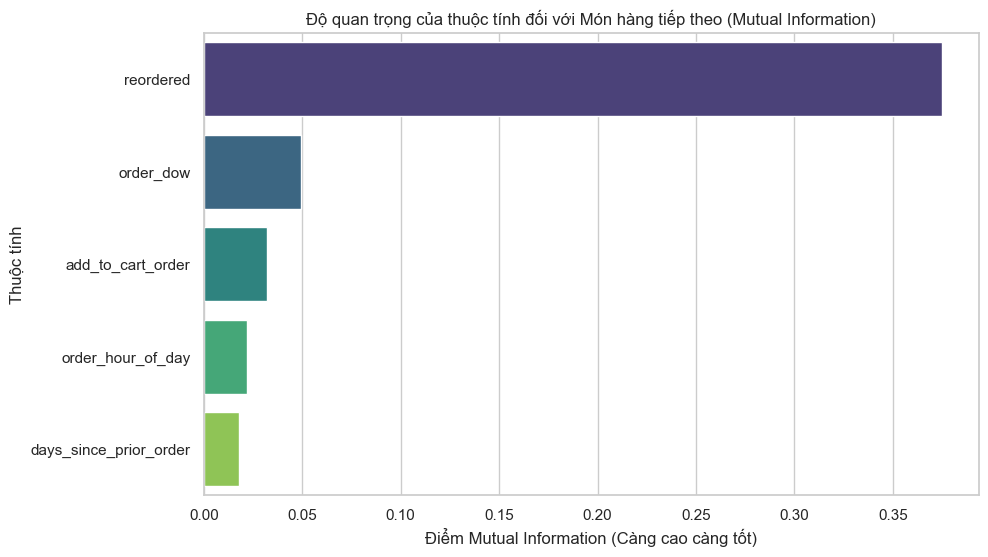

In [ ]:
#Đánh giá tương quan 
from sklearn.feature_selection import mutual_info_classif
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Đang tạo tập dữ liệu (X, y) để đánh giá thuộc tính...")

# 1. Sắp xếp lại dữ liệu theo user và thời gian mua
sorted_df = filtered_df.sort_values(by=['user_idx', 'order_number', 'add_to_cart_order'])

# 2. Tạo cột Target: Món hàng tiếp theo (Shift lên 1 dòng)
sorted_df['next_product_idx'] = sorted_df.groupby('user_idx')['product_idx'].shift(-1)

# Loại bỏ các dòng NaN (món hàng cuối cùng của mỗi user không có next item)
eval_df = sorted_df.dropna(subset=['next_product_idx']).copy()

# 3. Chọn các thuộc tính cần đánh giá
features_to_eval = ['order_dow', 'order_hour_of_day', 'days_since_prior_order', 'add_to_cart_order', 'reordered']
# order_dow (Ngày mua trong tuần)
# order_hour_of_day (Giờ mua trong ngày)
# days_since_prior_order (Số ngày kể từ lần mua trước)
# add_to_cart_order (Thứ tự món hàng được bỏ vào giỏ)

# Xử lý NaN cho days_since_prior_order (nếu là đơn đầu tiên) bằng cách điền 0
eval_df['days_since_prior_order'] = eval_df['days_since_prior_order'].fillna(0)

# Lấy một mẫu nhỏ (ví dụ 100,000 dòng) để tính toán cho nhanh, vì hàm MI chạy khá lâu trên dữ liệu lớn
sample_df = eval_df.sample(n=100000, random_state=42)

X = sample_df[features_to_eval]
y = sample_df['next_product_idx']

# 4. Tính toán Mutual Information
print("Đang chạy thuật toán Mutual Information...")
mi_scores = mutual_info_classif(X, y, random_state=42)

# 5. Trực quan hóa
mi_df = pd.DataFrame({'Feature': features_to_eval, 'MI_Score': mi_scores})
mi_df = mi_df.sort_values(by='MI_Score', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='MI_Score', y='Feature', data=mi_df, palette='viridis')
plt.title('Độ quan trọng của thuộc tính đối với Món hàng tiếp theo (Mutual Information)')
plt.xlabel('Điểm Mutual Information (Càng cao càng tốt)')
plt.ylabel('Thuộc tính')
plt.show()

Đang huấn luyện Random Forest để trích xuất Feature Importance...


C:\Users\DELL\AppData\Local\Temp\ipykernel_8740\2167812789.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')


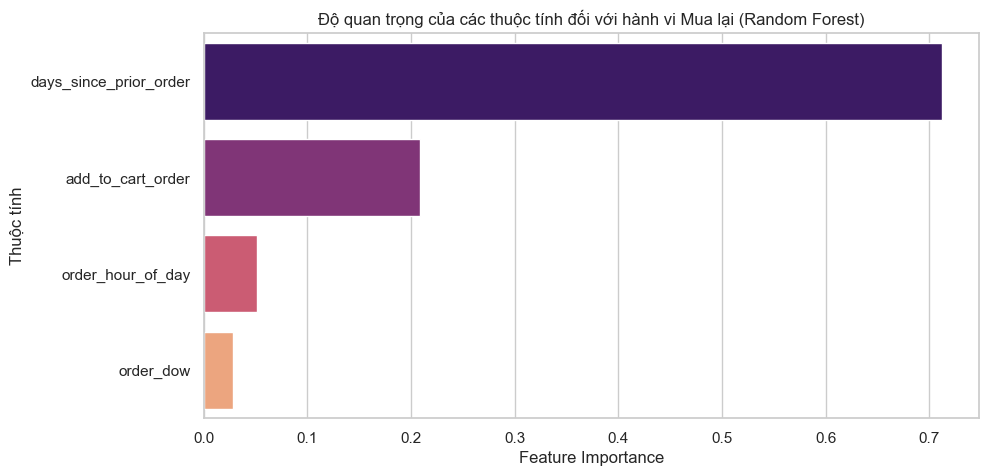

In [13]:
from sklearn.ensemble import RandomForestClassifier

# Trong bảng prior_df có sẵn cột 'reordered' (1 là mua lại, 0 là mua lần đầu)
# Chúng ta sẽ xem những thuộc tính thời gian ảnh hưởng thế nào đến việc mua lại

features = ['order_dow', 'order_hour_of_day', 'days_since_prior_order', 'add_to_cart_order']
X_rf = eval_df[features].fillna(0) # Tập dữ liệu
y_rf = eval_df['reordered']        # Biến mục tiêu

# Lấy mẫu 200,000 dòng để train nhanh
sample_idx = np.random.choice(X_rf.index, size=200000, replace=False)
X_train_rf = X_rf.loc[sample_idx]
y_train_rf = y_rf.loc[sample_idx]

# Khởi tạo và huấn luyện Random Forest
print("Đang huấn luyện Random Forest để trích xuất Feature Importance...")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train_rf, y_train_rf)

# Trích xuất độ quan trọng
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Trực quan hóa
plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')
plt.title('Độ quan trọng của các thuộc tính đối với hành vi Mua lại (Random Forest)')
plt.xlabel('Feature Importance')
plt.ylabel('Thuộc tính')
plt.show()

- Từ RF: Ta chứng minh được days_since_prior_order và add_to_cart_order là những yếu tố quyết định hành vi mua lại (Reorder) của người dùng.
- Từ MI: Ta chứng minh được hành vi Mua lại (reordered) lại là yếu tố quyết định mạnh nhất để dự đoán chính xác món hàng tiếp theo.
=> Vector Trạng thái (S_t) của Agent bắt buộc phải chứa cả ID sản phẩm lẫn 4 thuộc tính ngữ cảnh: order_dow, days_since_prior_order, add_to_cart_order và reordered để có thể gợi ý chính xác nhất
